# Variant Sweep Results Explorer

Use this notebook to inspect `run_variant_sweep.py` outputs, especially:
- successes where `min_crossings_found == 0`
- near-misses and failures for follow-up analysis


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd

try:
    import pyarrow.parquet as pq
except Exception:
    pq = None

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 140)


## 1) Configure Paths

Set `RUN_DIR` to the run you want to inspect. If left `None`, the latest run under `crossing-reduction/runs` is used.


In [3]:
from pathlib import Path

def resolve_base() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "runs").exists() and cwd.name == "crossing-reduction":
        return cwd
    if (cwd / "crossing-reduction").exists():
        return (cwd / "crossing-reduction").resolve()
    # Fallback for notebooks opened from unknown working directory
    return Path("crossing-reduction").resolve()

BASE = resolve_base()
RUNS_ROOT = BASE / "runs"

RUN_DIR = (RUNS_ROOT / "20260221_221918").resolve()
if not RUN_DIR.exists():
    raise FileNotFoundError(f"Configured RUN_DIR does not exist: {RUN_DIR}")

RESULTS_CSV = RUN_DIR / "results.csv"
METADATA_JSON = RUN_DIR / "metadata.json"

print("BASE:", BASE)
print("RUN_DIR:", RUN_DIR)
print("RESULTS_CSV exists:", RESULTS_CSV.exists())
print("METADATA_JSON exists:", METADATA_JSON.exists())


BASE: /Users/annedranowski/HQ/🔬 Research/Untangling Number/crossing-reduction
RUN_DIR: /Users/annedranowski/HQ/🔬 Research/Untangling Number/crossing-reduction/runs/20260221_221918
RESULTS_CSV exists: True
METADATA_JSON exists: True


## 2) Load Run Metadata + Results


In [4]:
meta = json.loads(METADATA_JSON.read_text(encoding="utf-8"))
results = pd.read_csv(RESULTS_CSV)

if "flipped_indices" in results.columns:
    results["flipped_indices"] = results["flipped_indices"].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

results["is_success"] = results["rl_unknot_success"].astype(bool)
results["is_zero"] = results["min_crossings_found"].astype(int).eq(0)

display(pd.DataFrame([meta]))
display(results.head())
print("rows:", len(results))


,started_at_utc,base,pd_path,pd_column,model_path,git_hash,seed,flips,episodes,deterministic,workers,chunk_size,use_tqdm,max_pds,max_variants,cfg
0,2026-02-22T06:19:18.495712+00:00,/Users/annedranowski/HQ/🔬 Research/Untangling Number/crossing-reduction,/Users/annedranowski/HQ/🔬 Research/Untangling Number/crossing-reduction/generated_T_pd_backtrack_1M.parquet,pd_json,/Users/annedranowski/HQ/🔬 Research/Untangling Number/crossing-reduction/best_model.zip,unknown,42,5,1,True,8,32,True,None,1000000,"{'max_steps': 500, 'step_penalty': 0.05, 'reward_finish': 10.0, 'allow_backtrack': True, 'cap_max': 8, 'mode_rewards': [3.0, 2.0, 1.0, 0.0]}"


,variant_id,source_index,original_crossings,flipped_indices,episodes,deterministic,rl_unknot_success,min_crossings_found,steps_taken_total,is_success,is_zero
0,"0:0,1,2,12,14",0,15,"[0, 1, 2, 12, 14]",1,True,False,7,500,False,False
1,"0:0,1,2,13,14",0,15,"[0, 1, 2, 13, 14]",1,True,False,9,500,False,False
2,"0:0,1,3,4,5",0,15,"[0, 1, 3, 4, 5]",1,True,False,5,500,False,False
3,"0:0,1,3,4,6",0,15,"[0, 1, 3, 4, 6]",1,True,False,5,500,False,False
4,"0:0,1,3,4,7",0,15,"[0, 1, 3, 4, 7]",1,True,False,5,500,False,False


rows: 1000000


## 3) High-Level Outcome Summary


In [5]:
summary = {
    "total": int(len(results)),
    "success_count": int(results["is_success"].sum()),
    "zero_count": int(results["is_zero"].sum()),
    "failure_count": int((~results["is_success"]).sum()),
    "mean_min_crossings": float(results["min_crossings_found"].mean()),
    "median_min_crossings": float(results["min_crossings_found"].median()),
}
display(pd.DataFrame([summary]))

display(results["min_crossings_found"].value_counts().sort_index().rename_axis("min_crossings_found").to_frame("count"))


,total,success_count,zero_count,failure_count,mean_min_crossings,median_min_crossings
0,1000000,85510,85510,914490,7.255133,7.0


,count
min_crossings_found,
0,85510
3,79276
4,66312
5,142465
6,38654
7,147191
8,48388
9,113791
10,59904


## 4) Load Source PD Pool (Parquet or TXT)

Uses `metadata.json -> pd_path` and supports:
- Parquet (`pd_json` or fallback columns)
- newline-delimited JSON txt


In [6]:
pd_path = Path(meta["pd_path"])
pd_column = meta.get("pd_column", "pd_json")

def load_pd_lines(path: Path, pd_column: str = "pd_json") -> list[str]:
    if path.suffix.lower() == ".parquet":
        if pq is None:
            raise RuntimeError("pyarrow is required to read parquet pools")
        table = pq.read_table(path)
        cols = set(table.column_names)
        use_col = pd_column if pd_column in cols else next((c for c in ["pd_json", "pd", "pd_code"] if c in cols), None)
        if use_col is None:
            raise ValueError(f"No PD column found in parquet file. columns={sorted(cols)}")
        out = []
        for v in table.column(use_col).to_pylist():
            if v is None:
                continue
            if isinstance(v, str):
                t = v.strip()
            else:
                t = json.dumps(v, separators=(",",":"))
            if t:
                out.append(t)
        return out

    return [ln.strip() for ln in path.read_text(encoding="utf-8").splitlines() if ln.strip()]

pd_lines = load_pd_lines(pd_path, pd_column=pd_column)
print("pd_path:", pd_path)
print("loaded PD lines:", len(pd_lines))


pd_path: /Users/annedranowski/HQ/🔬 Research/Untangling Number/crossing-reduction/generated_T_pd_backtrack_1M.parquet
loaded PD lines: 39


## 5) Reconstruct Variant PDs

Each result row identifies a variant by:
- `source_index` into source pool
- `flipped_indices` crossings to rotate


In [ ]:
def parse_pd_line_to_list(line: str):
    obj = json.loads(line)
    out = []
    for quad in obj:
        if len(quad) != 4:
            raise ValueError(f"Invalid quad: {quad}")
        out.append([int(x) for x in quad])
    return out

def flip_crossing_quad(quad):
    a, b, c, d = quad
    return [b, c, d, a]

def apply_flips(pd_list, flipped_indices):
    idxs = set(int(i) for i in flipped_indices)
    out = []
    for i, quad in enumerate(pd_list):
        out.append(flip_crossing_quad(quad) if i in idxs else list(quad))
    return out

base_pd_lists = [parse_pd_line_to_list(s) for s in pd_lines]

def attach_variant_pd(row):
    src = int(row["source_index"])
    flips = row["flipped_indices"]
    base = base_pd_lists[src]
    variant = apply_flips(base, flips)
    return pd.Series({
        "base_crossings": len(base),
        "variant_crossings": len(variant),
        "base_pd_json": json.dumps(base, separators=(",",":")),
        "variant_pd_json": json.dumps(variant, separators=(",",":")),
    })

enriched = results.join(results.apply(attach_variant_pd, axis=1))
display(enriched.head())


## 6) Successes (Zero-Minimum)


In [7]:
success_zero = enriched[enriched["is_zero"]].copy()
success_zero = success_zero.sort_values(["source_index", "variant_id"])

print("success_zero rows:", len(success_zero))
display(success_zero[["variant_id", "source_index", "flipped_indices", "min_crossings_found", "steps_taken_total", "variant_pd_json"]].head(50))


NameError: name 'enriched' is not defined

## 7) Failures and Near-Misses

Use this to inspect where the policy did not fully unknot.


In [ ]:
failures = enriched[~enriched["is_success"]].copy()
near_miss = enriched[(~enriched["is_zero"]) & (enriched["min_crossings_found"] <= 2)].copy()

print("failures:", len(failures))
print("near_miss (min<=2, non-zero):", len(near_miss))

display(near_miss[["variant_id", "source_index", "flipped_indices", "min_crossings_found", "steps_taken_total"]].head(50))


## 8) Export Subsets for Further Work


In [ ]:
EXPORT_DIR = RUN_DIR / "analysis"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

success_zero_path = EXPORT_DIR / "success_zero_variants.csv"
failure_path = EXPORT_DIR / "failures.csv"

success_zero.to_csv(success_zero_path, index=False)
failures.to_csv(failure_path, index=False)

print("wrote:", success_zero_path)
print("wrote:", failure_path)


## 9) Unique Base PDs Among Successes

This section inspects `analysis/success_zero_variants.csv` to test whether successes come from one base PD or many.


In [8]:
SUCCESS_ZERO_CSV = RUN_DIR / "analysis" / "success_zero_variants.csv"
if not SUCCESS_ZERO_CSV.exists():
    raise FileNotFoundError(f"Missing file: {SUCCESS_ZERO_CSV}")

sz = pd.read_csv(SUCCESS_ZERO_CSV)
print("success_zero rows:", len(sz))
print("columns:", list(sz.columns))

if "base_pd_json" not in sz.columns:
    raise KeyError("Column base_pd_json not found in success_zero_variants.csv")

base_counts = sz["base_pd_json"].value_counts(dropna=False).rename_axis("base_pd_json").to_frame("success_count")
n_unique = int(base_counts.shape[0])
print("unique base_pd_json among successes:", n_unique)

# Optional: tie back to source_index distribution
if "source_index" in sz.columns:
    src_counts = sz["source_index"].value_counts().sort_index().rename_axis("source_index").to_frame("success_count")
    display(src_counts.head(20))

display(base_counts.head(20))

summary = pd.DataFrame([{
    "success_rows": int(len(sz)),
    "unique_base_pd_json": n_unique,
    "max_successes_single_base": int(base_counts["success_count"].max()),
    "min_successes_single_base": int(base_counts["success_count"].min()),
}])
display(summary)


success_zero rows: 85510
columns: ['variant_id', 'source_index', 'original_crossings', 'flipped_indices', 'episodes', 'deterministic', 'rl_unknot_success', 'min_crossings_found', 'steps_taken_total', 'is_success', 'is_zero', 'base_crossings', 'variant_crossings', 'base_pd_json', 'variant_pd_json']
unique base_pd_json among successes: 39


,success_count
source_index,
0,792
1,940
2,1504
3,2480
4,3054
5,3824
6,2268
7,1980
8,5013


,success_count
base_pd_json,
"[[35,27,36,26],[27,35,28,34],[31,24,32,25],[25,28,26,29],[21,45,22,44],[13,51,14,50],[7,39,8,38],[3,43,4,42],[53,37,0,36],[47,17,48,16],[43,9,44,8],[39,7,40,6],[37,1,38,0],[11,3,12,2],[12,1,13,2],[41,5,42,4],[40,5,41,6],[45,21,46,20],[46,19,47,20],[32,51,33,52],[33,53,34,52],[18,10,19,9],[17,10,18,11],[23,30,24,31],[22,30,23,29],[15,49,16,48],[14,49,15,50]]",5072
"[[35,25,36,24],[25,29,26,28],[27,14,28,15],[15,26,16,27],[13,49,14,48],[7,53,8,52],[5,39,6,38],[1,45,2,44],[53,37,0,36],[49,13,50,12],[45,7,46,6],[41,3,42,2],[37,1,38,0],[16,29,17,30],[17,31,18,30],[11,51,12,50],[8,51,9,52],[34,21,35,22],[33,21,34,20],[10,47,11,48],[9,47,10,46],[18,31,19,32],[19,33,20,32],[22,23,23,24],[43,43,44,42],[3,41,4,40],[4,39,5,40]]",5013
"[[31,25,32,24],[25,31,26,30],[29,18,30,19],[23,26,24,27],[17,47,18,46],[13,51,14,50],[7,35,8,34],[1,43,2,42],[51,33,52,32],[47,15,48,14],[45,9,46,8],[37,7,38,6],[33,1,34,0],[28,20,29,19],[27,22,28,23],[10,16,11,15],[9,16,10,17],[53,21,0,20],[52,21,53,22],[35,36,36,37],[44,43,45,44],[5,39,6,38],[4,39,5,40],[48,11,49,12],[49,13,50,12],[41,3,42,2],[40,3,41,4]]",4673
"[[31,23,32,22],[23,31,24,30],[29,18,30,19],[21,24,22,25],[13,43,14,42],[11,45,12,44],[9,37,10,36],[5,39,6,38],[49,33,0,32],[43,13,44,12],[41,11,42,10],[37,9,38,8],[33,1,34,0],[35,34,36,35],[48,17,49,18],[45,15,46,14],[1,4,2,5],[28,20,29,19],[25,20,26,21],[2,4,3,3],[6,39,7,40],[7,41,8,40],[27,26,28,27],[16,47,17,48],[15,47,16,46]]",4566
"[[25,17,26,16],[17,23,18,22],[21,14,22,15],[15,18,16,19],[13,37,14,36],[7,49,8,48],[5,29,6,28],[1,33,2,32],[49,27,0,26],[47,9,48,8],[35,7,36,6],[29,5,30,4],[27,1,28,0],[33,34,34,35],[3,31,4,30],[2,31,3,32],[9,47,10,46],[10,39,11,40],[20,20,21,19],[43,42,44,43],[41,45,42,44],[40,45,41,46],[24,24,25,23],[11,39,12,38],[12,37,13,38]]",3840
"[[23,19,24,18],[19,23,20,22],[21,16,22,17],[17,20,18,21],[13,41,14,40],[9,45,10,44],[7,31,8,30],[1,39,2,38],[47,25,0,24],[43,11,44,10],[39,9,40,8],[31,7,32,6],[27,1,28,0],[33,5,34,4],[32,5,33,6],[14,15,15,16],[45,27,46,26],[46,25,47,26],[37,3,38,2],[36,3,37,4],[11,43,12,42],[12,41,13,42],[34,30,35,29],[35,28,36,29]]",3824
"[[35,21,36,20],[23,33,24,32],[31,12,32,13],[19,30,20,31],[11,47,12,46],[9,49,10,48],[7,39,8,38],[1,45,2,44],[49,37,0,36],[47,11,48,10],[45,9,46,8],[43,3,44,2],[37,1,38,0],[15,24,16,25],[18,30,19,29],[39,7,40,6],[42,3,43,4],[14,28,15,27],[13,28,14,29],[25,16,26,17],[26,18,27,17],[41,5,42,4],[40,5,41,6],[33,23,34,22],[34,21,35,22]]",3606
"[[21,15,22,14],[17,21,18,20],[19,12,20,13],[13,18,14,19],[11,37,12,36],[9,39,10,38],[5,33,6,32],[1,35,2,34],[39,23,40,22],[37,11,38,10],[35,9,36,8],[33,5,34,4],[31,1,32,0],[40,23,41,24],[43,29,44,28],[46,29,47,30],[47,31,0,30],[16,15,17,16],[41,43,42,42],[2,8,3,7],[3,6,4,7],[27,45,28,44],[24,45,25,46],[26,26,27,25]]",3588
"[[25,21,26,20],[21,25,22,24],[23,18,24,19],[19,22,20,23],[17,35,18,34],[5,47,6,46],[3,31,4,30],[1,33,2,32],[47,27,0,26],[41,11,42,10],[33,5,34,4],[31,3,32,2],[27,1,28,0],[11,41,12,40],[12,39,13,40],[29,29,30,28],[9,43,10,42],[8,43,9,44],[45,7,46,6],[44,7,45,8],[15,37,16,36],[16,35,17,36],[13,39,14,38],[14,37,15,38]]",3288


,success_rows,unique_base_pd_json,max_successes_single_base,min_successes_single_base
0,85510,39,5072,720


In [10]:
# Distribution of base PDs among successes (count and fraction)
base_pd_dist = (
    sz.groupby("base_pd_json")
      .size()
      .rename("unknotted_count")
      .sort_values(ascending=False)
      .to_frame()
)
base_pd_dist["share_of_successes"] = base_pd_dist["unknotted_count"] / max(len(sz), 1)

display(base_pd_dist)

# Optional concise view
# display(base_pd_dist.head(20))


,unknotted_count,share_of_successes
base_pd_json,,
"[[35,27,36,26],[27,35,28,34],[31,24,32,25],[25,28,26,29],[21,45,22,44],[13,51,14,50],[7,39,8,38],[3,43,4,42],[53,37,0,36],[47,17,48,16],[43,9,44,8],[39,7,40,6],[37,1,38,0],[11,3,12,2],[12,1,13,2],[41,5,42,4],[40,5,41,6],[45,21,46,20],[46,19,47,20],[32,51,33,52],[33,53,34,52],[18,10,19,9],[17,10,18,11],[23,30,24,31],[22,30,23,29],[15,49,16,48],[14,49,15,50]]",5072,0.059315
"[[35,25,36,24],[25,29,26,28],[27,14,28,15],[15,26,16,27],[13,49,14,48],[7,53,8,52],[5,39,6,38],[1,45,2,44],[53,37,0,36],[49,13,50,12],[45,7,46,6],[41,3,42,2],[37,1,38,0],[16,29,17,30],[17,31,18,30],[11,51,12,50],[8,51,9,52],[34,21,35,22],[33,21,34,20],[10,47,11,48],[9,47,10,46],[18,31,19,32],[19,33,20,32],[22,23,23,24],[43,43,44,42],[3,41,4,40],[4,39,5,40]]",5013,0.058625
"[[31,25,32,24],[25,31,26,30],[29,18,30,19],[23,26,24,27],[17,47,18,46],[13,51,14,50],[7,35,8,34],[1,43,2,42],[51,33,52,32],[47,15,48,14],[45,9,46,8],[37,7,38,6],[33,1,34,0],[28,20,29,19],[27,22,28,23],[10,16,11,15],[9,16,10,17],[53,21,0,20],[52,21,53,22],[35,36,36,37],[44,43,45,44],[5,39,6,38],[4,39,5,40],[48,11,49,12],[49,13,50,12],[41,3,42,2],[40,3,41,4]]",4673,0.054649
"[[31,23,32,22],[23,31,24,30],[29,18,30,19],[21,24,22,25],[13,43,14,42],[11,45,12,44],[9,37,10,36],[5,39,6,38],[49,33,0,32],[43,13,44,12],[41,11,42,10],[37,9,38,8],[33,1,34,0],[35,34,36,35],[48,17,49,18],[45,15,46,14],[1,4,2,5],[28,20,29,19],[25,20,26,21],[2,4,3,3],[6,39,7,40],[7,41,8,40],[27,26,28,27],[16,47,17,48],[15,47,16,46]]",4566,0.053397
"[[25,17,26,16],[17,23,18,22],[21,14,22,15],[15,18,16,19],[13,37,14,36],[7,49,8,48],[5,29,6,28],[1,33,2,32],[49,27,0,26],[47,9,48,8],[35,7,36,6],[29,5,30,4],[27,1,28,0],[33,34,34,35],[3,31,4,30],[2,31,3,32],[9,47,10,46],[10,39,11,40],[20,20,21,19],[43,42,44,43],[41,45,42,44],[40,45,41,46],[24,24,25,23],[11,39,12,38],[12,37,13,38]]",3840,0.044907
"[[23,19,24,18],[19,23,20,22],[21,16,22,17],[17,20,18,21],[13,41,14,40],[9,45,10,44],[7,31,8,30],[1,39,2,38],[47,25,0,24],[43,11,44,10],[39,9,40,8],[31,7,32,6],[27,1,28,0],[33,5,34,4],[32,5,33,6],[14,15,15,16],[45,27,46,26],[46,25,47,26],[37,3,38,2],[36,3,37,4],[11,43,12,42],[12,41,13,42],[34,30,35,29],[35,28,36,29]]",3824,0.044720
"[[35,21,36,20],[23,33,24,32],[31,12,32,13],[19,30,20,31],[11,47,12,46],[9,49,10,48],[7,39,8,38],[1,45,2,44],[49,37,0,36],[47,11,48,10],[45,9,46,8],[43,3,44,2],[37,1,38,0],[15,24,16,25],[18,30,19,29],[39,7,40,6],[42,3,43,4],[14,28,15,27],[13,28,14,29],[25,16,26,17],[26,18,27,17],[41,5,42,4],[40,5,41,6],[33,23,34,22],[34,21,35,22]]",3606,0.042171
"[[21,15,22,14],[17,21,18,20],[19,12,20,13],[13,18,14,19],[11,37,12,36],[9,39,10,38],[5,33,6,32],[1,35,2,34],[39,23,40,22],[37,11,38,10],[35,9,36,8],[33,5,34,4],[31,1,32,0],[40,23,41,24],[43,29,44,28],[46,29,47,30],[47,31,0,30],[16,15,17,16],[41,43,42,42],[2,8,3,7],[3,6,4,7],[27,45,28,44],[24,45,25,46],[26,26,27,25]]",3588,0.041960
"[[25,21,26,20],[21,25,22,24],[23,18,24,19],[19,22,20,23],[17,35,18,34],[5,47,6,46],[3,31,4,30],[1,33,2,32],[47,27,0,26],[41,11,42,10],[33,5,34,4],[31,3,32,2],[27,1,28,0],[11,41,12,40],[12,39,13,40],[29,29,30,28],[9,43,10,42],[8,43,9,44],[45,7,46,6],[44,7,45,8],[15,37,16,36],[16,35,17,36],[13,39,14,38],[14,37,15,38]]",3288,0.038452


## 10) Success Summary Visualizations

This block visualizes the descriptive summary outputs:
- `analysis/success_summary_descriptive_by_base.csv`
- `analysis/success_flip_index_enrichment_by_base.csv`


In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

analysis_dir = Path('runs/20260221_221918/analysis')
summary_csv = analysis_dir / 'success_summary_descriptive_by_base.csv'
enrich_csv = analysis_dir / 'success_flip_index_enrichment_by_base.csv'

summary_df = pd.read_csv(summary_csv)
enrich_df = pd.read_csv(enrich_csv)

summary_df = summary_df.sort_values('success_rate', ascending=False).reset_index(drop=True)

show_cols = [
    'source_index', 'base_crossings', 'total_variants', 'success_count',
    'success_rate', 'orig_crossings_min', 'orig_crossings_max', 'base_pd_json'
]
preview = summary_df[show_cols].copy()
preview['base_pd_json'] = preview['base_pd_json'].str.slice(0, 120) + ' ...'

print('summary rows:', len(summary_df))
print('enrichment rows:', len(enrich_df))
display(preview.head(10))


summary rows: 39
enrichment rows: 799


,source_index,base_crossings,total_variants,success_count,success_rate,orig_crossings_min,orig_crossings_max,base_pd_json
0,30,15,3003,840,0.279720,15,15,"[[17,13,18,12],[13,17,14,16],[15,10,16,11],[11,14,12,15],[9,25,10,24],[5,29,6,28],[3,21,4,20],[1,23,2,22],[29,19,0,18],[ ..."
1,24,15,3003,840,0.279720,15,15,"[[17,13,18,12],[13,17,14,16],[15,10,16,11],[11,14,12,15],[9,25,10,24],[5,29,6,28],[3,21,4,20],[1,23,2,22],[29,19,0,18],[ ..."
2,9,15,3003,804,0.267732,15,15,"[[17,13,18,12],[13,17,14,16],[15,8,16,9],[9,14,10,15],[7,27,8,26],[5,29,6,28],[3,21,4,20],[1,23,2,22],[29,19,0,18],[27,7 ..."
3,0,15,3003,792,0.263736,15,15,"[[17,13,18,12],[13,17,14,16],[15,10,16,11],[11,14,12,15],[9,27,10,26],[7,29,8,28],[5,21,6,20],[1,23,2,22],[29,19,0,18],[ ..."
4,17,15,3003,720,0.239760,15,15,"[[17,13,18,12],[13,17,14,16],[15,10,16,11],[11,14,12,15],[9,27,10,26],[7,29,8,28],[5,23,6,22],[3,25,4,24],[29,19,0,18],[ ..."
5,1,16,4368,940,0.215201,16,16,"[[17,13,18,12],[13,17,14,16],[15,10,16,11],[11,14,12,15],[9,27,10,26],[7,29,8,28],[5,21,6,20],[3,25,4,24],[29,19,30,18], ..."
6,18,17,6188,1272,0.205559,17,17,"[[17,13,18,12],[13,17,14,16],[15,10,16,11],[11,14,12,15],[9,29,10,28],[7,31,8,30],[5,23,6,22],[1,27,2,26],[31,19,32,18], ..."
7,21,17,6188,1272,0.205559,17,17,"[[19,15,20,14],[15,19,16,18],[17,12,18,13],[13,16,14,17],[11,31,12,30],[9,33,10,32],[5,23,6,22],[1,27,2,26],[33,21,0,20] ..."
8,10,17,6188,1260,0.203620,17,17,"[[21,17,22,16],[17,21,18,20],[19,14,20,15],[15,18,16,19],[13,31,14,30],[11,33,12,32],[7,25,8,24],[3,27,4,26],[33,23,0,22 ..."
9,20,17,6188,1224,0.197802,17,17,"[[17,13,18,12],[13,17,14,16],[15,10,16,11],[11,14,12,15],[9,29,10,28],[5,33,6,32],[3,23,4,22],[1,27,2,26],[33,19,0,18],[ ..."


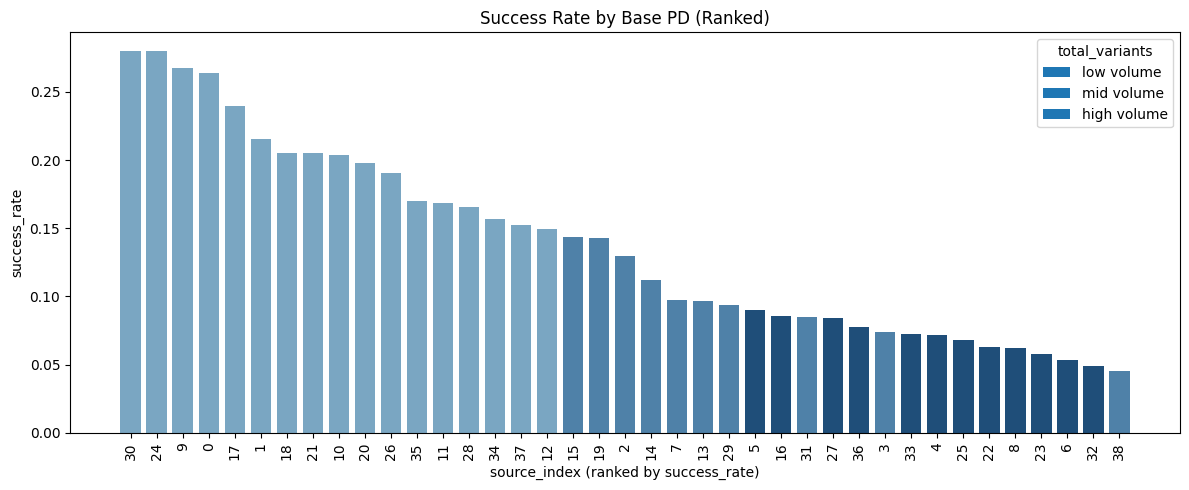

,source_index,base_crossings,total_variants,success_count,success_rate
0,30,15,3003,840,0.279720
1,24,15,3003,840,0.279720
2,9,15,3003,804,0.267732
3,0,15,3003,792,0.263736
4,17,15,3003,720,0.239760
5,1,16,4368,940,0.215201
6,18,17,6188,1272,0.205559
7,21,17,6188,1272,0.205559
8,10,17,6188,1260,0.203620
9,20,17,6188,1224,0.197802


In [15]:
# Success rate by base PD (source_index), colored by total variant volume
plot_df = summary_df.copy() # .sort_values('success_rate', ascending=False).copy()

# Volume bins for visual context
plot_df['volume_bin'] = pd.qcut(plot_df['total_variants'], q=3, labels=['low volume', 'mid volume', 'high volume'])
bin_colors = {'low volume': '#7aa6c2', 'mid volume': '#4f81a8', 'high volume': '#1f4e79'}
colors = plot_df['volume_bin'].map(bin_colors)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plot_df['source_index'].astype(str), plot_df['success_rate'], color=colors)
ax.set_title('Success Rate by Base PD (Ranked)')
ax.set_xlabel('source_index (ranked by success_rate)')
ax.set_ylabel('success_rate')
ax.tick_params(axis='x', rotation=90)

# Legend
for label, color in bin_colors.items():
    ax.bar([], [], color=color, label=label)
ax.legend(title='total_variants')

plt.tight_layout()
plt.show()

display(plot_df[['source_index', 'base_crossings', 'total_variants', 'success_count', 'success_rate']].head(10))


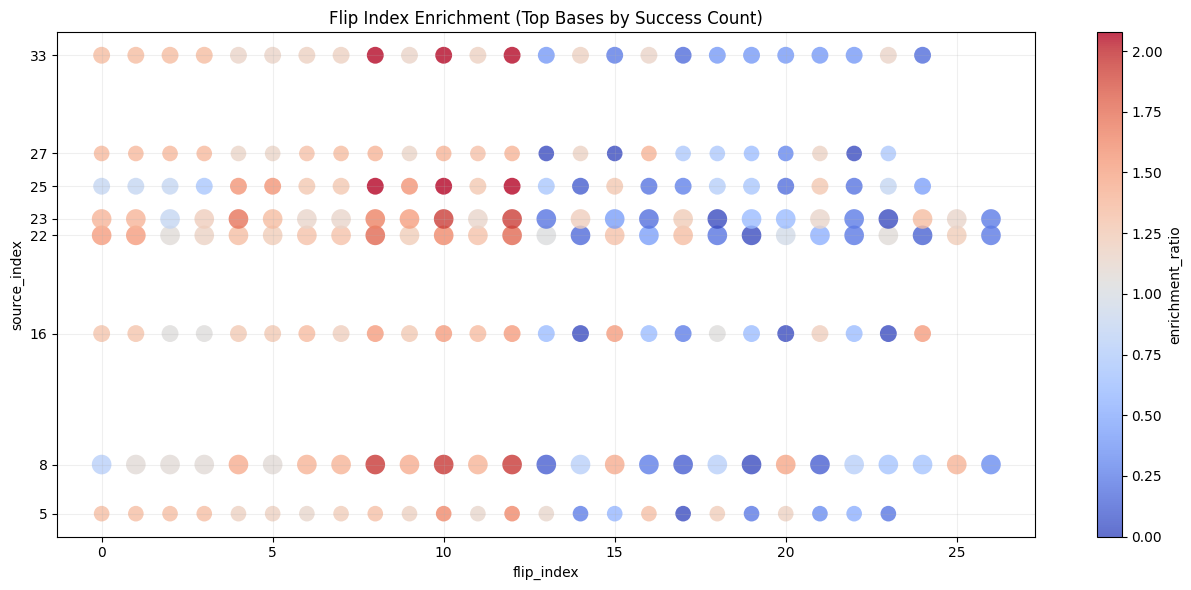

,source_index,flip_index,index_total_count,index_success_rate,base_success_rate,enrichment_ratio
512,25,12,10626,0.140975,0.067871,2.077094
508,25,8,10626,0.140975,0.067871,2.077094
510,25,10,10626,0.140975,0.067871,2.077094
682,33,12,10626,0.149068,0.072276,2.062500
680,33,10,10626,0.149068,0.072276,2.062500
678,33,8,10626,0.149068,0.072276,2.062500
178,8,12,14950,0.121739,0.062096,1.960503
176,8,10,14950,0.121739,0.062096,1.960503
174,8,8,14950,0.121739,0.062096,1.960503
468,23,10,14950,0.112642,0.057884,1.945988


In [13]:
# Flip-index enrichment: success rate when index is flipped / base success rate
top_n_bases = 8  # change as desired
top_bases = summary_df.sort_values('success_count', ascending=False).head(top_n_bases)['source_index'].tolist()
plot_e = enrich_df[enrich_df['source_index'].isin(top_bases)].copy()

# keep most informative points
plot_e = plot_e[plot_e['index_total_count'] >= 100]
plot_e = plot_e.sort_values(['source_index', 'enrichment_ratio'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(13, 6))
sc = ax.scatter(
    plot_e['flip_index'],
    plot_e['source_index'],
    c=plot_e['enrichment_ratio'],
    s=(plot_e['index_total_count'] / plot_e['index_total_count'].max()) * 180 + 20,
    cmap='coolwarm',
    alpha=0.8,
    edgecolors='none'
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('enrichment_ratio')

ax.set_title('Flip Index Enrichment (Top Bases by Success Count)')
ax.set_xlabel('flip_index')
ax.set_ylabel('source_index')
ax.set_yticks(sorted(top_bases))
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Table: strongest enriched indices per selected base
top_enriched = (
    plot_e.sort_values('enrichment_ratio', ascending=False)
         .groupby('source_index', as_index=False)
         .head(5)
         [['source_index', 'flip_index', 'index_total_count', 'index_success_rate', 'base_success_rate', 'enrichment_ratio']]
)
display(top_enriched)
